# Telegram Public-Channel Analysis

A worked analysis of a population of **public** Telegram channels harvested and scored by
this project's crawler. For each channel we collect open metadata and aggregate post
statistics, then compute engagement metrics and a **0–100 health score**.

> **Data note.** This notebook runs on a **synthetic** sample
> (`data/sample/channels_sample.csv`, 3 000 fabricated channels) so it is fully
> reproducible and ships no real user data. The metrics (`ERR`, `reach`) and the
> `preliminary_score` are generated with the **same formulas the production code uses**
> (`utils/metrics.py`, `services/preliminary_scorer.py`), so the shapes and relationships
> below mirror what the real crawl produces.

**Questions we answer:**
1. How is audience size distributed? (the long tail)
2. How does engagement scale with channel size?
3. Which categories dominate, and are some healthier than others?
4. What actually drives the health score?
5. Can we flag channels with **inauthentic / bought** audiences?
6. Do channels fall into natural segments?


In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('.')  # notebook runs from notebooks/
from generate_sample import err_score, reach_score, comments_score, freq_score, subs_score

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'font.size': 10})
BLUE, ORANGE, GREY = '#2b6cb0', '#dd6b20', '#a0aec0'

df = pd.read_csv('../data/sample/channels_sample.csv')
print(f'{len(df):,} channels, {df.shape[1]} columns')
df.head()

3,000 channels, 15 columns


,username,title,subscribers,avg_views,avg_reactions,avg_comments,avg_forwards,posts_per_day,has_linked_chat,err,reach,bot_ratio,detected_category,preliminary_score,health_score
0,@entertainment_nova_0000,Peak Vibes,21073,6033,115,0,16,2.38,False,2.70,28.63,0.054,entertainment,60.0,58.0
1,@sports_neon_0001,Insider Match,3668,717,17,0,3,0.04,False,3.19,19.57,0.115,sports,35.0,32.6
2,@business_insider_0002,Daily Market,666,251,6,0,2,3.65,False,4.62,37.78,0.081,business,52.0,49.5
3,@news_daily_0003,Peak Report,6798,2657,24,0,8,2.72,False,1.61,39.10,0.000,news,57.0,57.0
4,@business_insider_0004,Quiet Capital,5935,2118,71,15,26,1.37,True,5.54,35.70,0.036,business,87.0,85.1


## Dataset overview

In [2]:
summary = df[['subscribers','avg_views','err','reach','posts_per_day',
               'bot_ratio','preliminary_score','health_score']].describe().T
summary[['mean','std','min','25%','50%','75%','max']].round(2)

,mean,std,min,25%,50%,75%,max
subscribers,14851.42,73823.94,100.00,1341.50,3995.50,11913.25,3000000.00
avg_views,3282.64,12883.49,3.00,367.00,1039.00,2797.75,416925.00
err,3.30,1.79,0.02,1.97,3.20,4.48,10.25
reach,28.11,10.44,0.20,21.71,28.96,35.16,60.52
posts_per_day,2.94,5.80,0.00,0.76,1.70,2.60,40.00
bot_ratio,0.09,0.15,0.00,0.03,0.05,0.08,0.90
preliminary_score,57.26,13.71,8.20,49.88,57.00,65.00,92.00
health_score,54.57,14.80,5.90,46.40,55.00,64.00,90.00


## 1. The audience long tail

Channel size spans four orders of magnitude, so we look at it on a log scale. As in real
social data, a handful of large channels hold most of the total reach.

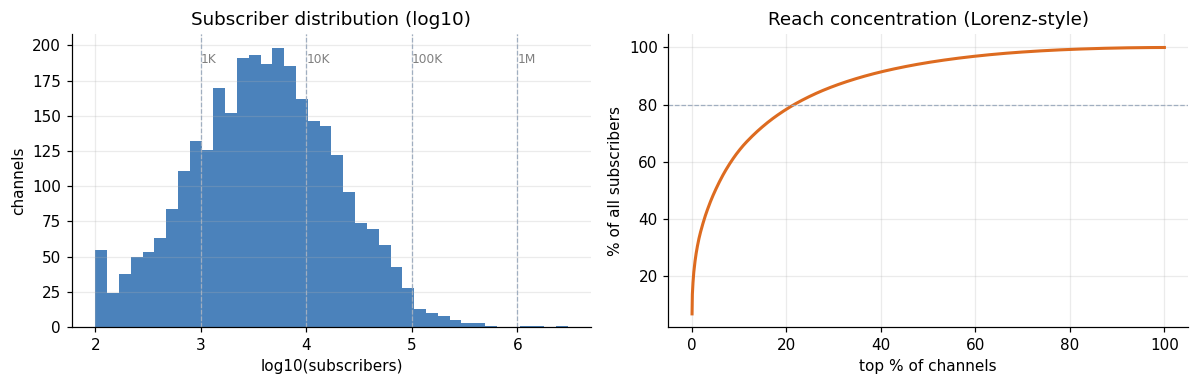

Top 10% of channels hold 64% of all subscribers.


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

logsubs = np.log10(df['subscribers'])
ax[0].hist(logsubs, bins=40, color=BLUE, alpha=.85)
ax[0].set(title='Subscriber distribution (log10)', xlabel='log10(subscribers)', ylabel='channels')
for t, x in [('1K', 3), ('10K', 4), ('100K', 5), ('1M', 6)]:
    ax[0].axvline(x, color=GREY, ls='--', lw=.8); ax[0].text(x, ax[0].get_ylim()[1]*.9, t, color='grey', fontsize=8)

s = df['subscribers'].sort_values(ascending=False).values
share = np.cumsum(s) / s.sum()
ax[1].plot(np.arange(1, len(s)+1) / len(s) * 100, share * 100, color=ORANGE, lw=2)
ax[1].set(title='Reach concentration (Lorenz-style)', xlabel='top % of channels', ylabel='% of all subscribers')
ax[1].axhline(80, color=GREY, ls='--', lw=.8)
plt.tight_layout(); plt.show()

top10_share = share[int(len(s)*0.10)] * 100
print(f'Top 10% of channels hold {top10_share:.0f}% of all subscribers.')

## 2. Engagement vs size

Two core metrics:
- **ERR** — Engagement Rate = (reactions + comments + forwards) / views · 100
- **Reach** — views / subscribers · 100

Smaller channels almost always punch above their weight on engagement; reach decays as an
audience grows (and as bots dilute it).

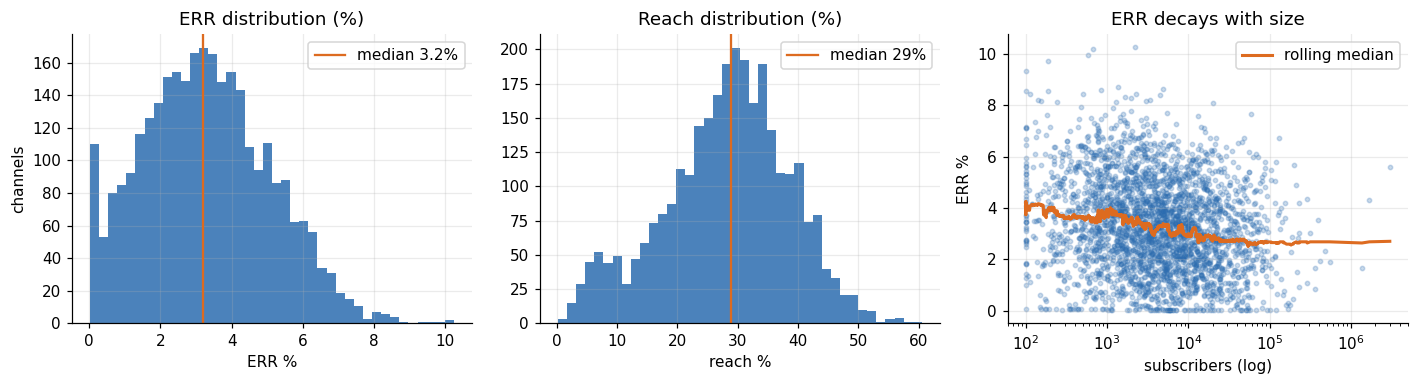

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))

ax[0].hist(df['err'], bins=40, color=BLUE, alpha=.85)
ax[0].set(title='ERR distribution (%)', xlabel='ERR %', ylabel='channels')
ax[0].axvline(df['err'].median(), color=ORANGE, lw=1.5, label=f"median {df['err'].median():.1f}%"); ax[0].legend()

ax[1].hist(df['reach'], bins=40, color=BLUE, alpha=.85)
ax[1].set(title='Reach distribution (%)', xlabel='reach %')
ax[1].axvline(df['reach'].median(), color=ORANGE, lw=1.5, label=f"median {df['reach'].median():.0f}%"); ax[1].legend()

ax[2].scatter(df['subscribers'], df['err'], s=8, alpha=.25, color=BLUE)
ax[2].set(title='ERR decays with size', xlabel='subscribers (log)', ylabel='ERR %', xscale='log')
# rolling median of ERR over size
o = df.sort_values('subscribers')
roll = o['err'].rolling(150, min_periods=30).median()
ax[2].plot(o['subscribers'], roll, color=ORANGE, lw=2, label='rolling median')
ax[2].legend()
plt.tight_layout(); plt.show()

## 3. Categories: who's here, and who's healthy

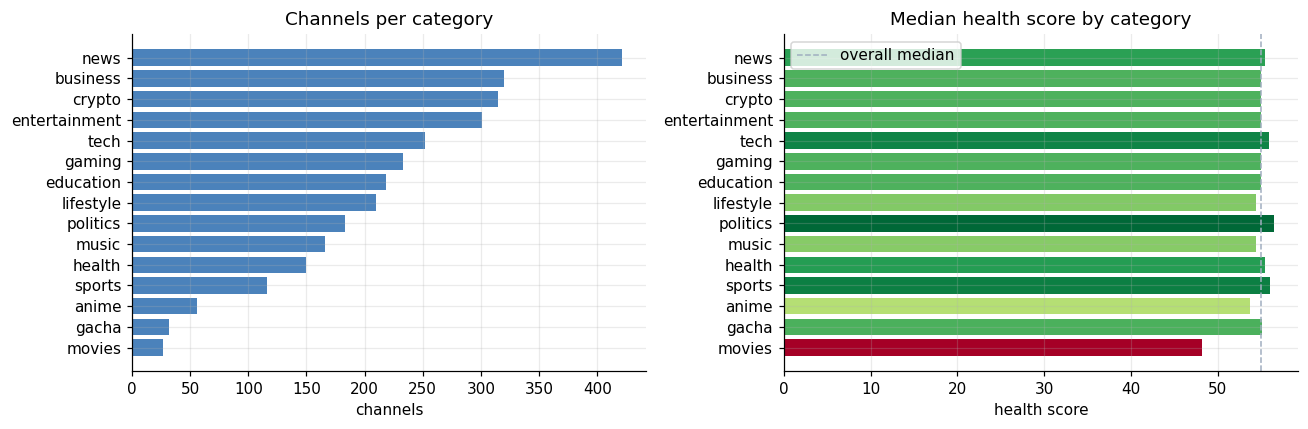

In [5]:
order = df['detected_category'].value_counts()
med_health = df.groupby('detected_category')['health_score'].median().reindex(order.index)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].barh(order.index[::-1], order.values[::-1], color=BLUE, alpha=.85)
ax[0].set(title='Channels per category', xlabel='channels')

colors = plt.cm.RdYlGn((med_health.values - med_health.min()) / (med_health.max() - med_health.min()))
ax[1].barh(med_health.index[::-1], med_health.values[::-1], color=colors[::-1])
ax[1].set(title='Median health score by category', xlabel='health score')
ax[1].axvline(df['health_score'].median(), color=GREY, ls='--', lw=1, label='overall median'); ax[1].legend()
plt.tight_layout(); plt.show()

## 4. What drives the health score?

The `preliminary_score` (0–100) is a weighted sum of five components, exactly as in
`services/preliminary_scorer.py`:

| component | max | rewards |
|---|---|---|
| ERR | 25 | genuine engagement |
| reach | 25 | views relative to audience |
| comments | 20 | a real discussion (linked chat) |
| frequency | 15 | a healthy posting cadence (~1–3/day) |
| subscribers | 15 | audience size |

The **health score** then discounts this by the share of inauthentic audience:
`health = preliminary · (1 − 0.6 · bot_ratio)`. We recompute the components here (importing
the very same scoring functions) to see what typically wins or loses points.

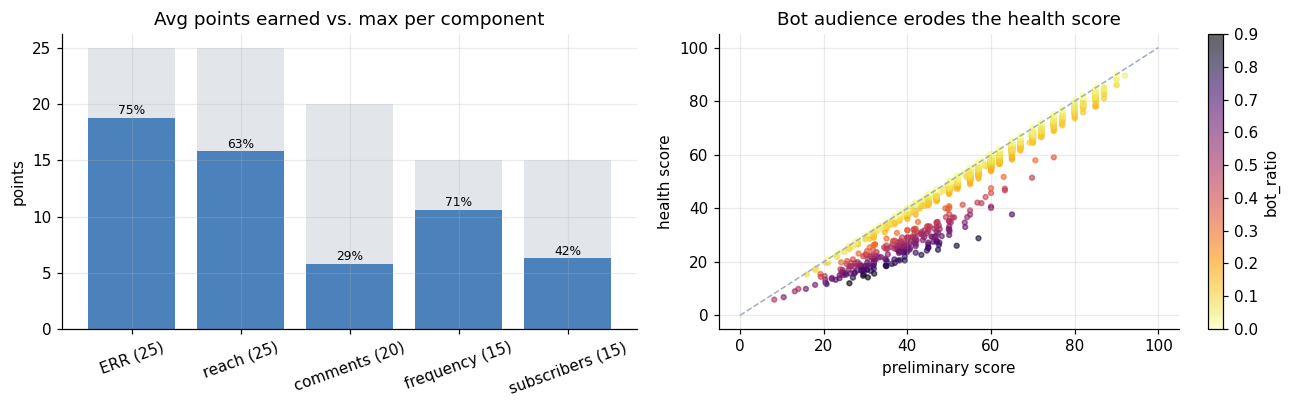

Comments is the most-often-missed component: 60% of channels score 0 there (no linked discussion chat).


In [6]:
comp = pd.DataFrame({
    'ERR (25)':         df['err'].map(err_score),
    'reach (25)':       df['reach'].map(reach_score),
    'comments (20)':    [comments_score(h, c) for h, c in zip(df['has_linked_chat'], df['avg_comments'])],
    'frequency (15)':   df['posts_per_day'].map(freq_score),
    'subscribers (15)': df['subscribers'].map(subs_score),
})
means = comp.mean().round(1)
maxes = {'ERR (25)':25,'reach (25)':25,'comments (20)':20,'frequency (15)':15,'subscribers (15)':15}
pct = (means / pd.Series(maxes) * 100).round(0)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].bar(means.index, means.values, color=BLUE, alpha=.85)
ax[0].bar(means.index, [maxes[k]-means[k] for k in means.index], bottom=means.values, color=GREY, alpha=.3)
ax[0].set(title='Avg points earned vs. max per component', ylabel='points')
ax[0].tick_params(axis='x', rotation=20)
for i, k in enumerate(means.index): ax[0].text(i, means[k]+.3, f'{pct[k]:.0f}%', ha='center', fontsize=8)

sc = ax[1].scatter(df['preliminary_score'], df['health_score'], c=df['bot_ratio'],
                   cmap='inferno_r', s=10, alpha=.6)
ax[1].plot([0,100],[0,100], color=GREY, ls='--', lw=1)
ax[1].set(title='Bot audience erodes the health score', xlabel='preliminary score', ylabel='health score')
fig.colorbar(sc, ax=ax[1], label='bot_ratio')
plt.tight_layout(); plt.show()

print('Comments is the most-often-missed component:',
      f"{(comp['comments (20)']==0).mean()*100:.0f}% of channels score 0 there (no linked discussion chat).")

## 5. Flagging inauthentic audiences

A channel is **suspicious** if it shows the classic bought-audience signature: a large
subscriber count that isn't backed by views or engagement, or an outright high bot ratio.

234 of 3000 channels flagged suspicious (7.8%).
                      clean  suspicious
median subscribers  3943.50     4368.00
median reach %        29.76        7.41
median ERR %           3.38        1.41
median health         56.30       25.05


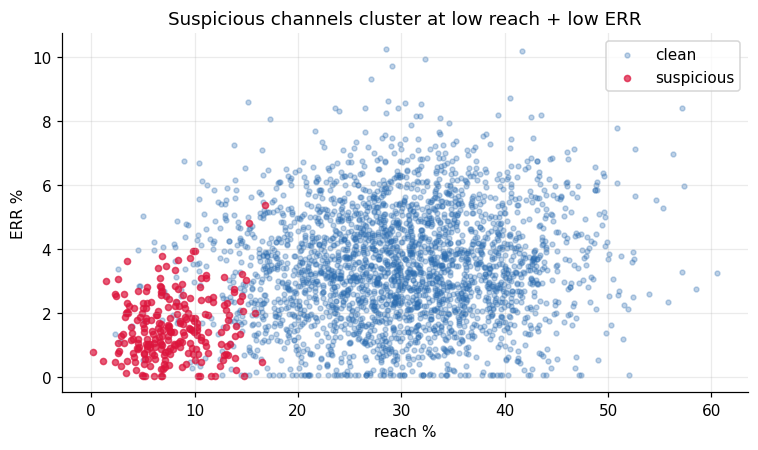

In [7]:
df['suspicious'] = (
    (df['bot_ratio'] > 0.30) |
    ((df['subscribers'] > 20000) & (df['reach'] < 8) & (df['err'] < 1.0))
)
n = int(df['suspicious'].sum())
print(f'{n} of {len(df)} channels flagged suspicious ({n/len(df)*100:.1f}%).')

clean, susp = df[~df['suspicious']], df[df['suspicious']]
tbl = pd.DataFrame({
    'clean':      [clean['subscribers'].median(), clean['reach'].median(), clean['err'].median(), clean['health_score'].median()],
    'suspicious': [susp['subscribers'].median(),  susp['reach'].median(),  susp['err'].median(),  susp['health_score'].median()],
}, index=['median subscribers','median reach %','median ERR %','median health']).round(2)
print(tbl.to_string())

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.scatter(clean['reach'], clean['err'], s=10, alpha=.3, color=BLUE, label='clean')
ax.scatter(susp['reach'], susp['err'], s=16, alpha=.7, color='crimson', label='suspicious')
ax.set(title='Suspicious channels cluster at low reach + low ERR',
       xlabel='reach %', ylabel='ERR %'); ax.legend()
plt.tight_layout(); plt.show()

## 6. Natural segments (k-means)

Standardising a handful of features and clustering surfaces recognisable channel
archetypes without any labels.

         channels  med_subs  med_err  med_reach  med_bot  med_health
segment                                                             
0            1339   11030.0     2.70      25.49     0.05       56.30
1            1294    1360.0     4.10      34.17     0.05       57.00
2             235    4462.0     1.42       7.40     0.56       25.20
3             132    3509.5     3.28      30.60     0.05       45.15


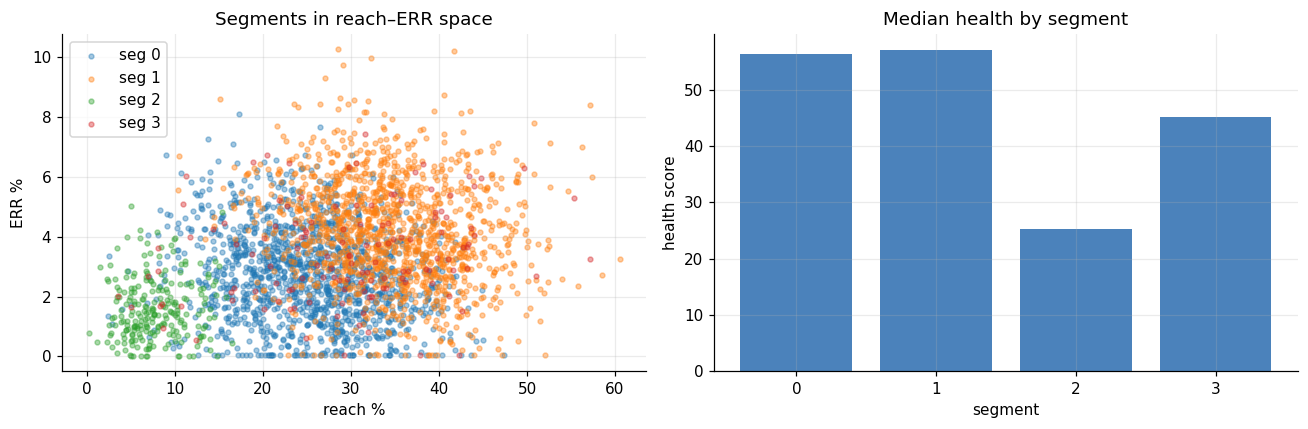

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

feat = pd.DataFrame({
    'log_subs': np.log10(df['subscribers']),
    'err': df['err'], 'reach': df['reach'],
    'bot_ratio': df['bot_ratio'], 'posts_per_day': df['posts_per_day'],
})
X = StandardScaler().fit_transform(feat)
df['segment'] = KMeans(n_clusters=4, n_init=10, random_state=7).fit_predict(X)

profile = df.groupby('segment').agg(
    channels=('username','size'),
    med_subs=('subscribers','median'),
    med_err=('err','median'),
    med_reach=('reach','median'),
    med_bot=('bot_ratio','median'),
    med_health=('health_score','median'),
).round(2)
print(profile.to_string())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for seg in sorted(df['segment'].unique()):
    d = df[df['segment']==seg]
    ax[0].scatter(d['reach'], d['err'], s=10, alpha=.4, label=f'seg {seg}')
ax[0].set(title='Segments in reach–ERR space', xlabel='reach %', ylabel='ERR %'); ax[0].legend()
ax[1].bar(profile.index.astype(str), profile['med_health'], color=BLUE, alpha=.85)
ax[1].set(title='Median health by segment', xlabel='segment', ylabel='health score')
plt.tight_layout(); plt.show()

## 7. Key findings

- **Reach is highly concentrated** — the top 10% of channels hold the large majority of all
  subscribers; any ranking that ignores this over-weights a few giants.
- **Engagement is inversely related to size.** Small channels carry the highest ERR; a raw
  view count flatters big channels that are actually coasting.
- **The most commonly *missed* score component is discussion** — a large share of channels
  have no linked comment chat and score zero there, which is the cheapest lever for a
  channel owner to improve.
- **~1 in 8 channels shows a bought-audience signature** (high subscribers, dead reach and
  ERR, or an outright high bot ratio). The health score's bot discount separates these from
  genuinely healthy channels that the raw preliminary score would rank alongside them.
- **K-means recovers interpretable archetypes** — e.g. *healthy niche* (small, high ERR &
  reach), *large & coasting*, *vanity / bought* (high subs, low reach, high bots) and
  *dormant* — a useful basis for downstream targeting or moderation.

*Next steps on real data:* validate the bot heuristic against manually-labelled channels,
add posting-time and text-topic features, and track health scores over time to catch decay.
